# Análise Exploratória do Catálogo da Netflix

## Objetivo

Este projeto tem como objetivo realizar uma análise exploratória dos dados do catálogo da Netflix, buscando identificar padrões relacionados aos tipos de conteúdo, países de origem, gêneros, classificações, duração e evolução dos títulos ao longo dos anos.

### Tecnologias utilizadas

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/netflix_titles.csv")

## 1. Conhecendo os dados

Antes de realizar o tratamento e a análise, será feita uma exploração inicial da base para entender sua estrutura, tipos de dados, valores ausentes e possíveis duplicatas.


In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

### Observações iniciais

- O conjunto de dados possui 8.807 registros e 12 variáveis.
- Não foram identificados registros completamente duplicados.
- Foram identificados valores ausentes nas colunas `director`, `cast`, `country`, `date_added`, `rating` e `duration`.
- A coluna `director` apresenta a maior quantidade de valores ausentes, com 2.634 registros sem informação.
- A coluna `date_added` está armazenada como texto e deverá ser convertida para o formato de data.
- Os valores ausentes serão analisados antes de qualquer remoção ou preenchimento.

In [8]:
(df.isnull().sum() / len(df) * 100).round(2)

show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64

In [9]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [10]:
df["rating"].value_counts(dropna=False)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NaN            4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [11]:
df["duration"].value_counts(dropna=False)

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
             ... 
228 min         1
18 min          1
205 min         1
201 min         1
191 min         1
Name: count, Length: 221, dtype: int64

In [12]:
df[df["rating"].str.contains("min", na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [13]:
df[df["duration"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [14]:
df[df["rating"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


## 2. Limpeza e tratamento dos dados

Nesta etapa, serão tratados problemas identificados durante a exploração inicial, incluindo valores ausentes, informações armazenadas em colunas incorretas e tipos de dados inadequados.

In [15]:
filtro_duracao = df["rating"].str.contains("min", na=False)

df.loc[filtro_duracao, "duration"] = df.loc[filtro_duracao, "rating"]

df.loc[filtro_duracao, "rating"] = pd.NA

In [16]:
df[df["duration"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [17]:
df["rating"].value_counts(dropna=False)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
NaN            7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

### Correção de inconsistências

Foram identificados três registros em que valores de duração estavam armazenados incorretamente na coluna `rating`, enquanto a coluna `duration` estava vazia.

Os valores foram transferidos para a coluna `duration` e as respectivas classificações foram definidas como ausentes, pois não havia informação suficiente para determinar seus valores corretos.

In [18]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")

In [19]:
df["date_added"] = pd.to_datetime(
    df["date_added"].str.strip(),
    format="%B %d, %Y",
    errors="coerce"
)

In [20]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [21]:
df["duration_minutes"] = (
    df.loc[df["type"] == "Movie", "duration"]
    .str.replace(" min", "", regex=False)
    .astype("Int64")
)

In [22]:
df[["type", "duration", "duration_minutes"]].head(10)

,type,duration,duration_minutes
0,Movie,90 min,90
1,TV Show,2 Seasons,<NA>
2,TV Show,1 Season,<NA>
3,TV Show,1 Season,<NA>
4,TV Show,2 Seasons,<NA>
5,TV Show,1 Season,<NA>
6,Movie,91 min,91
7,Movie,125 min,125
8,TV Show,9 Seasons,<NA>
9,Movie,104 min,104


In [23]:
df["seasons"] = (
    df.loc[df["type"] == "TV Show", "duration"]
    .str.extract(r"(\d+)")[0]
    .astype("Int64")
)

In [24]:
df[["type", "duration", "duration_minutes", "seasons"]].head(15)

,type,duration,duration_minutes,seasons
0,Movie,90 min,90,<NA>
1,TV Show,2 Seasons,<NA>,2
2,TV Show,1 Season,<NA>,1
3,TV Show,1 Season,<NA>,1
4,TV Show,2 Seasons,<NA>,2
5,TV Show,1 Season,<NA>,1
6,Movie,91 min,91,<NA>
7,Movie,125 min,125,<NA>
8,TV Show,9 Seasons,<NA>,9
9,Movie,104 min,104,<NA>


### Preparação das variáveis de duração

A coluna `duration` apresenta informações diferentes dependendo do tipo de conteúdo: duração em minutos para filmes e quantidade de temporadas para séries.

Para facilitar as análises, foram criadas duas novas variáveis:

- `duration_minutes`: duração dos filmes em minutos.
- `seasons`: quantidade de temporadas das séries.

In [25]:
df["listed_in"].head(10)

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
5                   TV Dramas, TV Horror, TV Mysteries
6                             Children & Family Movies
7     Dramas, Independent Movies, International Movies
8                         British TV Shows, Reality TV
9                                     Comedies, Dramas
Name: listed_in, dtype: str

In [26]:
generos = df[["show_id", "title", "type", "listed_in"]].copy()

generos["listed_in"] = generos["listed_in"].str.split(",")

generos = generos.explode("listed_in")

generos["listed_in"] = generos["listed_in"].str.strip()

generos = generos.rename(columns={"listed_in": "genre"})

In [27]:
generos.head(10)

,show_id,title,type,genre
0,s1,Dick Johnson Is Dead,Movie,Documentaries
1,s2,Blood & Water,TV Show,International TV Shows
1,s2,Blood & Water,TV Show,TV Dramas
1,s2,Blood & Water,TV Show,TV Mysteries
2,s3,Ganglands,TV Show,Crime TV Shows
2,s3,Ganglands,TV Show,International TV Shows
2,s3,Ganglands,TV Show,TV Action & Adventure
3,s4,Jailbirds New Orleans,TV Show,Docuseries
3,s4,Jailbirds New Orleans,TV Show,Reality TV
4,s5,Kota Factory,TV Show,International TV Shows


In [28]:
generos["genre"].value_counts().head(10)

genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

### Preparação dos gêneros

A coluna `listed_in` pode conter múltiplas categorias para um mesmo título. Para permitir a análise individual dos gêneros, foi criado um DataFrame auxiliar.

As categorias foram separadas e transformadas em registros individuais, mantendo o conjunto de dados principal inalterado.

## 3. Análise Exploratória dos Dados

Nesta etapa, serão exploradas as principais características do catálogo, buscando responder perguntas sobre a distribuição dos conteúdos, gêneros, países de origem, classificações, duração e evolução ao longo dos anos.

### 3.1 Distribuição entre filmes e séries

Nesta análise, será avaliada a distribuição dos títulos do catálogo entre filmes e séries.

In [29]:
df["type"].value_counts()


type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [30]:
df["type"].value_counts(normalize=True) * 100

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

In [31]:
contagem_tipos = df["type"].value_counts()

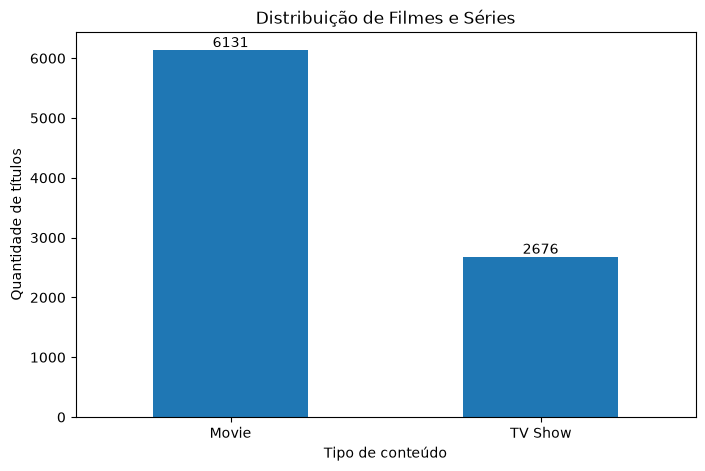

In [32]:
plt.figure(figsize=(8, 5))

ax = contagem_tipos.plot(kind="bar")

plt.title("Distribuição de Filmes e Séries")
plt.xlabel("Tipo de conteúdo")
plt.ylabel("Quantidade de títulos")

plt.xticks(rotation=0)

ax.bar_label(ax.containers[0])

plt.show()

**Conclusão:**  
O catálogo analisado é composto majoritariamente por filmes. Dos 8.807 títulos presentes na base, 6.131 são filmes e 2.676 são séries, representando aproximadamente 69,6% e 30,4% do catálogo, respectivamente.

### 3.2 Evolução do catálogo ao longo dos anos

Nesta análise, será avaliada a quantidade de títulos adicionados ao catálogo da Netflix em cada ano.

In [33]:
df["year_added"] = df["date_added"].dt.year.astype("Int64")

In [34]:
df[["date_added", "year_added"]].head()

,date_added,year_added
0,2021-09-25,2021
1,2021-09-24,2021
2,2021-09-24,2021
3,2021-09-24,2021
4,2021-09-24,2021


In [35]:
titulos_por_ano = df["year_added"].value_counts().sort_index()
titulos_por_ano

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: Int64

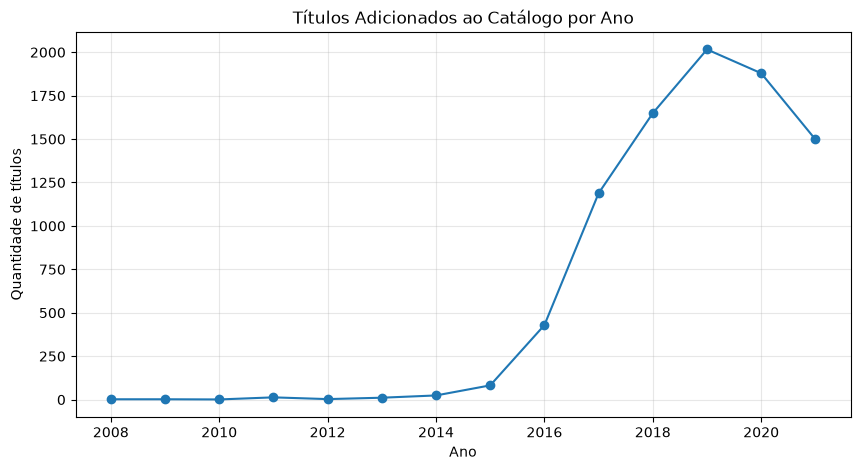

In [36]:
plt.figure(figsize=(10, 5))

titulos_por_ano.plot(kind="line", marker="o")

plt.title("Títulos Adicionados ao Catálogo por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de títulos")

plt.grid(alpha=0.3)

plt.show()

In [37]:
df["date_added"].max()

Timestamp('2021-09-25 00:00:00')

In [38]:
df["date_added"].min()

Timestamp('2008-01-01 00:00:00')

**Conclusão:**  
A quantidade de títulos adicionados ao catálogo apresentou forte crescimento a partir de 2016, atingindo seu pico em 2019, com 2.016 títulos adicionados. Em 2020, foram registrados 1.879 novos títulos.

Em 2021, a base apresenta 1.498 títulos adicionados. No entanto, os dados desse ano estão disponíveis somente até 25 de setembro, portanto não é possível comparar diretamente esse valor com anos completos nem concluir que houve uma queda anual nas adições.

### 3.3 Gêneros mais presentes no catálogo

Nesta análise, serão identificadas as categorias mais frequentes entre os títulos disponíveis no catálogo.

In [39]:
top_generos = generos["genre"].value_counts().head(10)

In [40]:
top_generos

genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

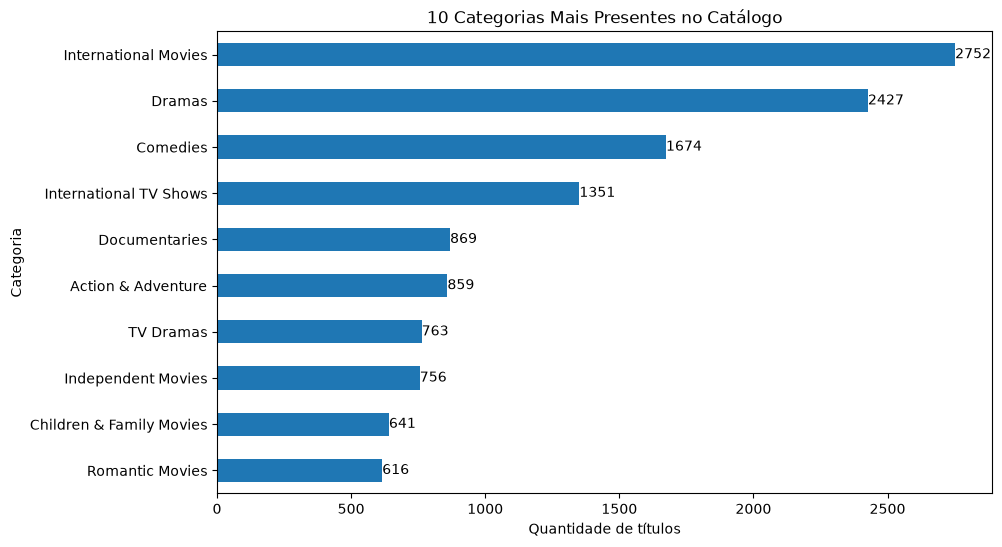

In [41]:
plt.figure(figsize=(10, 6))

ax = top_generos.sort_values().plot(kind="barh")

plt.title("10 Categorias Mais Presentes no Catálogo")
plt.xlabel("Quantidade de títulos")
plt.ylabel("Categoria")

ax.bar_label(ax.containers[0])

plt.show()

**Conclusão:**  
`International Movies` é a categoria mais frequente no catálogo analisado, presente em 2.752 títulos, seguida por `Dramas`, com 2.427, e `Comedies`, com 1.674.

Como um mesmo título pode pertencer a múltiplas categorias, as contagens representam ocorrências de cada categoria e não títulos exclusivos.

### 3.4 Países com maior presença no catálogo

Nesta análise, serão identificados os países com maior número de produções presentes no catálogo.

In [42]:
paises = df[["show_id", "title", "type", "country"]].copy()

In [43]:
paises["country"] = paises["country"].str.split(",")

In [44]:
paises = paises.explode("country")

In [45]:
paises["country"] = paises["country"].str.strip()

In [46]:
top_paises = (
    paises[paises["country"] != "Unknown"]["country"]
    .value_counts()
    .head(10)
)

In [47]:
top_paises

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

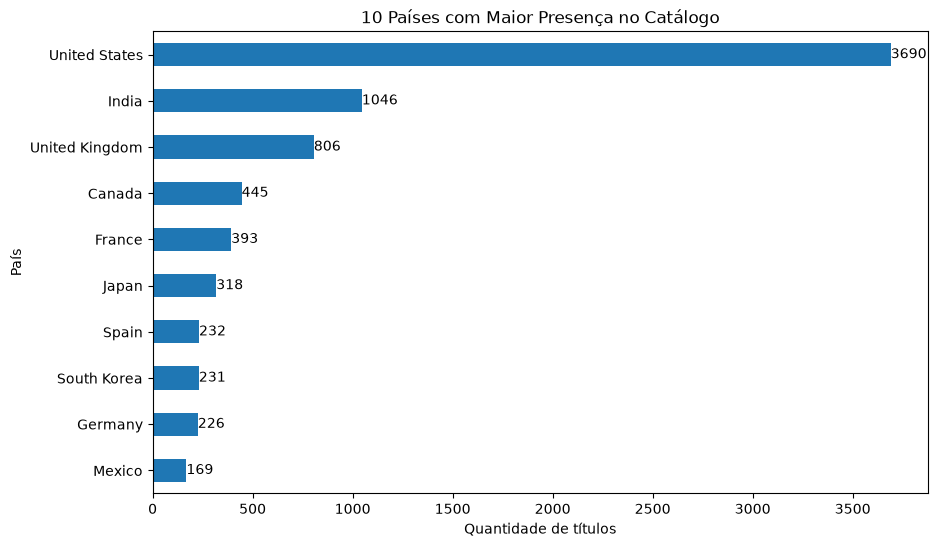

In [48]:
plt.figure(figsize=(10, 6))

ax = top_paises.sort_values().plot(kind="barh")

plt.title("10 Países com Maior Presença no Catálogo")
plt.xlabel("Quantidade de títulos")
plt.ylabel("País")

ax.bar_label(ax.containers[0])

plt.show()

**Conclusão:**  
Os Estados Unidos apresentam a maior presença entre as produções do catálogo, com 3.690 ocorrências, valor significativamente superior ao da Índia, que ocupa a segunda posição com 1.046, seguida pelo Reino Unido, com 806.

Como uma mesma produção pode estar associada a mais de um país, os valores representam ocorrências de países nas produções e não quantidades exclusivas de títulos.

### 3.5 Duração dos filmes

Nesta análise, será investigada a distribuição da duração dos filmes presentes no catálogo, considerando medidas como média, mediana, mínimo e máximo.

In [49]:
duracao_filmes = df.loc[
    df["type"] == "Movie",
    "duration_minutes"
]

In [50]:
duracao_filmes.head(10)

0      90
6      91
7     125
9     104
12    127
13     91
16     67
18     94
22    161
23     61
Name: duration_minutes, dtype: Int64

In [51]:
duracao_filmes.describe()

count       6131.0
mean     99.564998
std      28.289504
min            3.0
25%           87.0
50%           98.0
75%          114.0
max          312.0
Name: duration_minutes, dtype: Float64

In [52]:
duracao_filmes.min()

np.int64(3)

In [53]:
duracao_filmes.max()

np.int64(312)

In [54]:
duracao_filmes.max()

np.int64(312)

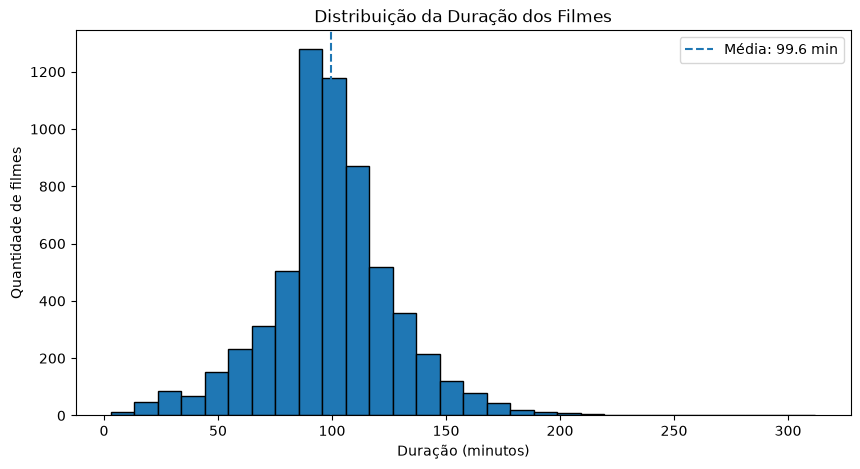

In [55]:
plt.figure(figsize=(10, 5))

plt.hist(duracao_filmes.dropna(), bins=30, edgecolor="black")

plt.axvline(
    duracao_filmes.mean(),
    linestyle="--",
    label=f"Média: {duracao_filmes.mean():.1f} min"
)

plt.title("Distribuição da Duração dos Filmes")
plt.xlabel("Duração (minutos)")
plt.ylabel("Quantidade de filmes")

plt.legend()

plt.show()

In [56]:
df.loc[
    df["type"] == "Movie",
    ["title", "duration_minutes"]
].sort_values("duration_minutes").head(10)

,title,duration_minutes
3777,Silent,3
2713,Sol Levante,5
1484,Cops and Robbers,8
1557,Canvas,9
3535,American Factory: A Conversation with the Obamas,10
2858,Calico Critters: Everyone's Big Dream Flying i...,11
6405,Calico Critters: A Town of Dreams,11
695,Besieged Bread,12
3775,Cosmos Laundromat: First Cycle,12
4707,Zion,12


In [57]:
df.loc[
    df["type"] == "Movie",
    ["title", "duration_minutes"]
].sort_values("duration_minutes", ascending=False).head(10)

,title,duration_minutes
4253,Black Mirror: Bandersnatch,312
717,Headspace: Unwind Your Mind,273
2491,The School of Mischief,253
2487,No Longer kids,237
2484,Lock Your Girls In,233
2488,Raya and Sakina,230
166,Once Upon a Time in America,229
7932,Sangam,228
1019,Lagaan,224
4573,Jodhaa Akbar,214


**Conclusão:**  
Os filmes presentes no catálogo possuem duração média de aproximadamente 99,6 minutos e mediana de 98 minutos. Metade dos filmes apresenta duração entre 87 e 114 minutos, indicando uma concentração próxima de 1h30 a 2h.

Também foram identificadas produções com durações muito curtas e muito longas, variando entre 3 e 312 minutos. Esses valores foram mantidos na análise, pois representam produções presentes na própria base e não foram identificados como erros de preenchimento.

### 3.6 Quantidade de temporadas das séries

Nesta análise, será investigada a distribuição da quantidade de temporadas das séries presentes no catálogo.

In [58]:
temporadas_series = df.loc[
    df["type"] == "TV Show",
    "seasons"
]

In [59]:
temporadas_series.describe()

count      2676.0
mean     1.764948
std      1.582752
min           1.0
25%           1.0
50%           1.0
75%           2.0
max          17.0
Name: seasons, dtype: Float64

In [60]:
temporadas_series.value_counts().sort_index()

seasons
1     1793
2      425
3      199
4       95
5       65
6       33
7       23
8       17
9        9
10       7
11       2
12       2
13       3
15       2
17       1
Name: count, dtype: Int64

In [61]:
(temporadas_series.value_counts(normalize=True).sort_index() * 100).round(2)

seasons
1      67.0
2     15.88
3      7.44
4      3.55
5      2.43
6      1.23
7      0.86
8      0.64
9      0.34
10     0.26
11     0.07
12     0.07
13     0.11
15     0.07
17     0.04
Name: proportion, dtype: Float64

In [62]:
contagem_temporadas = temporadas_series.value_counts().sort_index()

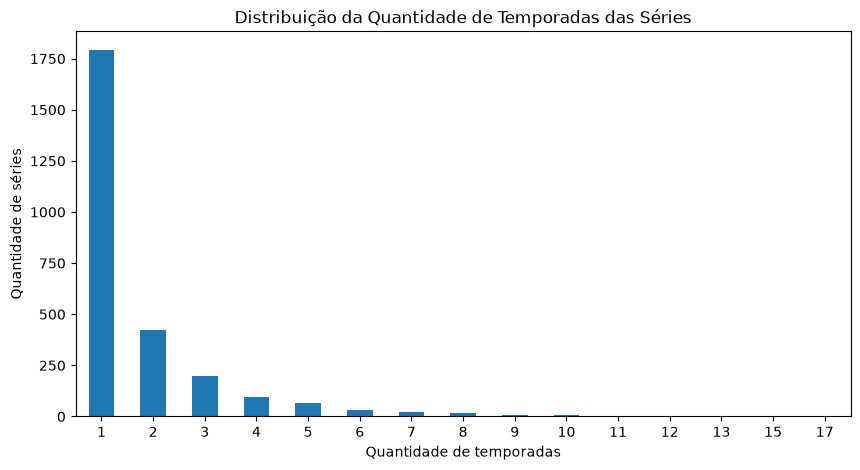

In [63]:
plt.figure(figsize=(10, 5))

ax = contagem_temporadas.plot(kind="bar")

plt.title("Distribuição da Quantidade de Temporadas das Séries")
plt.xlabel("Quantidade de temporadas")
plt.ylabel("Quantidade de séries")

plt.xticks(rotation=0)

plt.show()

**Conclusão:**  
A maioria das séries presentes no catálogo possui poucas temporadas. Das 2.676 séries analisadas, 1.793 possuem apenas uma temporada, correspondendo a aproximadamente 67% do total.

Séries com duas temporadas representam cerca de 15,9%, enquanto aquelas com três temporadas representam aproximadamente 7,4%. A mediana de uma temporada reforça a forte concentração de produções com apenas uma temporada no catálogo.

### 3.7 Classificações indicativas mais frequentes

Nesta análise, será investigada a distribuição das classificações indicativas dos títulos presentes no catálogo.

In [64]:
df["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [65]:
(df["rating"].value_counts(normalize=True) * 100).round(2)

rating
TV-MA       36.41
TV-14       24.53
TV-PG        9.80
R            9.07
PG-13        5.56
TV-Y7        3.79
TV-Y         3.49
PG           3.26
TV-G         2.50
NR           0.91
G            0.47
Unknown      0.08
TV-Y7-FV     0.07
NC-17        0.03
UR           0.03
Name: proportion, dtype: float64

In [66]:
top_ratings = (
    df[df["rating"] != "Unknown"]["rating"]
    .value_counts()
    .head(10)
)

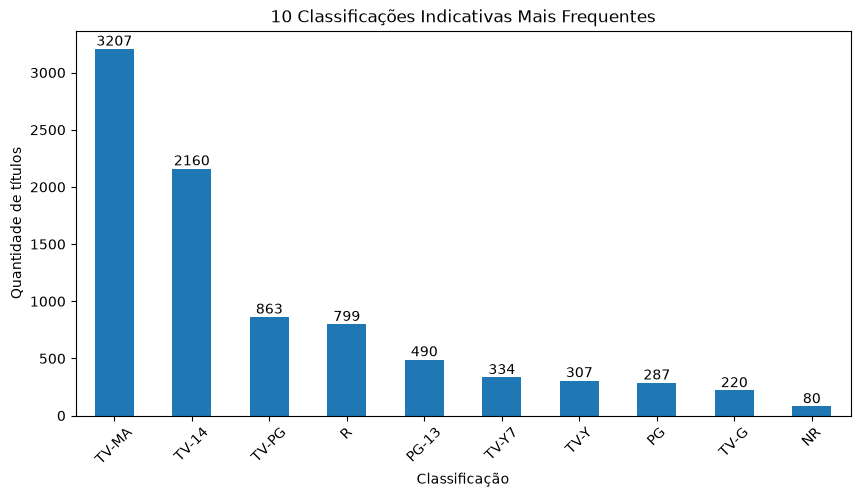

In [67]:
plt.figure(figsize=(10, 5))

ax = top_ratings.plot(kind="bar")

plt.title("10 Classificações Indicativas Mais Frequentes")
plt.xlabel("Classificação")
plt.ylabel("Quantidade de títulos")

plt.xticks(rotation=45)

ax.bar_label(ax.containers[0])

plt.show()

**Conclusão:**  
A classificação `TV-MA` é a mais frequente no catálogo, presente em 3.207 títulos e representando aproximadamente 36,4% do total. Em seguida aparece `TV-14`, com 2.160 títulos (24,5%), enquanto `TV-PG` ocupa a terceira posição, com 863 títulos (9,8%).

Os resultados mostram uma forte concentração nas classificações `TV-MA` e `TV-14`, que juntas representam aproximadamente 60,9% dos títulos analisados.

### 3.8 Evolução de filmes e séries ao longo dos anos

Nesta análise, será comparada a evolução da quantidade de filmes e séries adicionados ao catálogo ao longo dos anos.

In [68]:
evolucao_tipo = (
    df.groupby(["year_added", "type"])
    .size()
    .unstack()
)

In [69]:
evolucao_tipo

type,Movie,TV Show
year_added,,
2008,1.0,1.0
2009,2.0,NaN
2010,1.0,NaN
2011,13.0,NaN
2012,3.0,NaN
2013,6.0,5.0
2014,19.0,5.0
2015,56.0,26.0
2016,253.0,176.0


In [70]:
evolucao_tipo.sum()

type
Movie      6131.0
TV Show    2666.0
dtype: float64

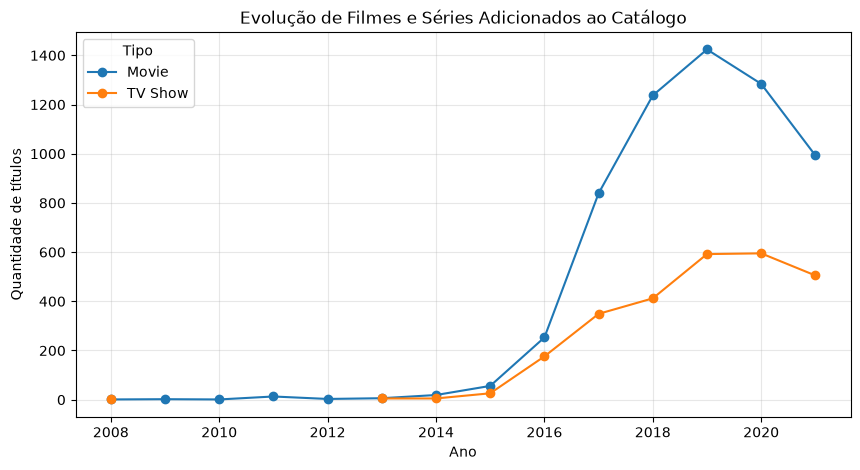

In [71]:
evolucao_tipo.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Evolução de Filmes e Séries Adicionados ao Catálogo")
plt.xlabel("Ano")
plt.ylabel("Quantidade de títulos")

plt.grid(alpha=0.3)
plt.legend(title="Tipo")

plt.show()

**Conclusão:**  
A quantidade de filmes e séries adicionados ao catálogo apresentou forte crescimento principalmente a partir de 2016. Os filmes tiveram uma expansão mais acentuada, atingindo o pico em 2019, com 1.424 títulos adicionados.

As séries apresentaram crescimento mais gradual e atingiram seu maior valor em 2020, com 595 títulos adicionados. Embora os filmes permaneçam em maior quantidade durante todo o período analisado, a diferença entre os dois tipos diminuiu nos anos mais recentes.

Os dados de 2021 devem ser interpretados com cautela, pois a base contém registros somente até 25 de setembro daquele ano.

## 4. Conclusões Gerais

A análise do catálogo permitiu identificar os principais padrões relacionados aos tipos de conteúdo, gêneros, países de origem, duração, quantidade de temporadas e evolução das adições ao longo do tempo.

### Principais insights

- **Filmes predominam no catálogo:** dos 8.807 títulos analisados, 6.131 são filmes e 2.676 são séries, representando aproximadamente 69,6% e 30,4% do catálogo, respectivamente.

- **O catálogo apresentou forte expansão ao longo dos anos:** o crescimento das adições se intensificou principalmente a partir de 2016, com pico geral em 2019.

- **Produções internacionais possuem forte presença:** `International Movies` foi a categoria mais frequente, seguida por `Dramas` e `Comedies`.

- **Os Estados Unidos apresentam a maior presença entre os países associados às produções**, com 3.690 ocorrências, seguidos por Índia e Reino Unido.

- **Os filmes possuem duração próxima de 100 minutos:** a duração média foi de aproximadamente 99,6 minutos e a mediana de 98 minutos.

- **Séries com apenas uma temporada predominam:** aproximadamente 67% das séries analisadas possuem somente uma temporada.

- **TV-MA é a classificação indicativa mais frequente**, representando aproximadamente 36,4% dos títulos, seguida por TV-14, com cerca de 24,5%.

- **Filmes e séries apresentaram comportamentos diferentes ao longo do tempo:** os filmes atingiram seu pico de adições em 2019, enquanto as séries atingiram seu maior valor em 2020.

### Limitações

Os dados de 2021 estão disponíveis somente até 25 de setembro, portanto esse período não deve ser comparado diretamente com anos completos.

Além disso, um mesmo título pode estar associado a múltiplos gêneros e países. Por esse motivo, as análises dessas categorias representam ocorrências e não necessariamente quantidades exclusivas de títulos.